# Handwritten Digit Classification using Multiple Supervised Learning Algorithms

## Objective
To compare different supervised learning algorithms for classifying handwritten digits 
and analyze their performance using statistical evaluation metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
digits = load_digits()

X = digits.data      # features (64)
y = digits.target    # labels (0-9)

print("Dataset shape:", X.shape)

Dataset shape: (1797, 64)


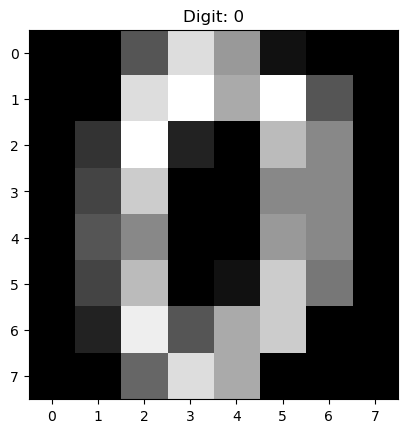

In [3]:
plt.imshow(digits.images[0], cmap='gray')
plt.title("Digit: " + str(y[0]))
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1437
Testing samples: 360


In [5]:
log_model = LogisticRegression(max_iter=10000)
log_model.fit(X_train, y_train)

log_train_acc = accuracy_score(y_train, log_model.predict(X_train))
log_test_acc = accuracy_score(y_test, log_model.predict(X_test))

In [6]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

knn_train_acc = accuracy_score(y_train, knn_model.predict(X_train))
knn_test_acc = accuracy_score(y_test, knn_model.predict(X_test))

In [7]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train))
svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test))

In [8]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "SVM"],
    "Training Accuracy": [log_train_acc, knn_train_acc, svm_train_acc],
    "Testing Accuracy": [log_test_acc, knn_test_acc, svm_test_acc]
})

results

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,1.000000,0.975000
1,KNN,0.993041,0.983333
2,SVM,0.996521,0.986111


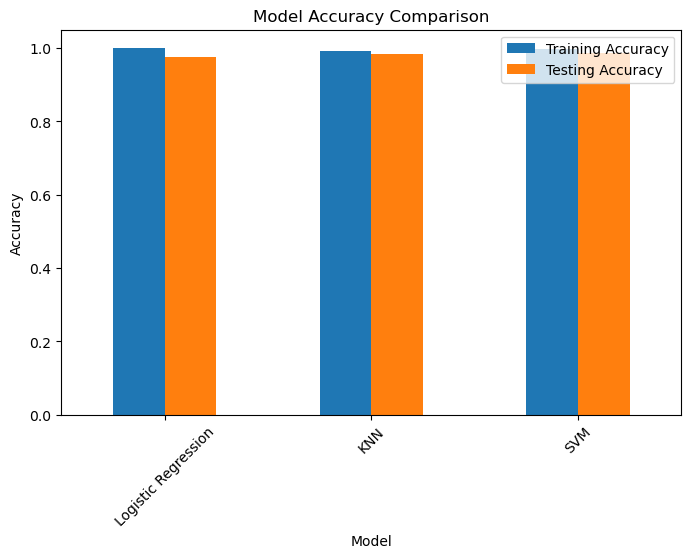

In [9]:
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

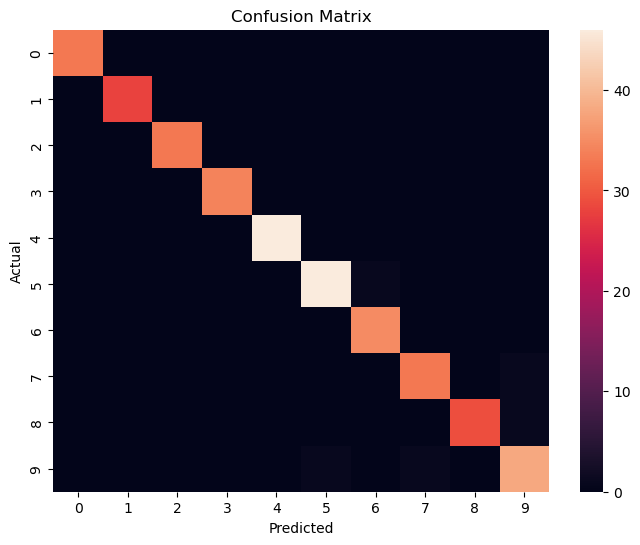

In [10]:
best_model = svm_model  
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [12]:
print("Training Accuracy:", results["Training Accuracy"])
print("Testing Accuracy:", results["Testing Accuracy"])

Training Accuracy: 0    1.000000
1    0.993041
2    0.996521
Name: Training Accuracy, dtype: float64
Testing Accuracy: 0    0.975000
1    0.983333
2    0.986111
Name: Testing Accuracy, dtype: float64


In [13]:
print(X.shape)

(1797, 64)


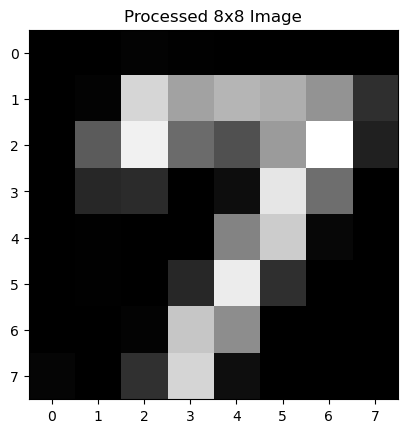

Predicted Digit: 7


In [14]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("my_digit.png").convert("L")

# Resize to 8x8
img = img.resize((8, 8), Image.LANCZOS)

# Convert to numpy
img_array = np.array(img)

# Scale pixel values from 0–255 → 0–16
img_array = img_array / 255.0 * 16

# Invert colors (sklearn digits are light digit on dark background)
img_array = 16 - img_array

# Flatten to 64 features
img_flat = img_array.flatten().reshape(1, -1)

# Show what model sees
plt.imshow(img_array.reshape(8,8), cmap='gray')
plt.title("Processed 8x8 Image")
plt.show()

# Predict
prediction = svm_model.predict(img_flat)
print("Predicted Digit:", prediction[0])